# Обязательное ДЗ№8. Решить задачу сегментации кружочков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

learning_rate = 3e-4
batch_size = 32
epochs = 10

device

device(type='cuda')

In [2]:
from dataset import DataGenerator
import os

x_size, y_size = 572, 572

train_samples = batch_size * 20
val_samples = batch_size * 4
test_samples = batch_size * 2

if not os.path.exists("./data/train.npz"):
    os.makedirs("./data", exist_ok=True)
    data_generator = DataGenerator()

    data_generator.generate_data(x_size, y_size, train_samples)
    data_generator.save_data("./data/train.npz")

    data_generator.generate_data(x_size, y_size, val_samples)
    data_generator.save_data("./data/val.npz")

    data_generator.generate_data(x_size, y_size, test_samples)
    data_generator.save_data("./data/test.npz")
else:
    print("Data already exists")

Data already exists


In [3]:
from dataset import TrainDataset, TestDataset
from torch.utils.data import DataLoader
import os

train_dataset = TrainDataset("./data/train.npz")
val_dataset = TrainDataset("./data/val.npz")
test_dataset = TestDataset("./data/test.npz")

is_cuda = (hasattr(device, "type") and device.type == "cuda") or (str(device) == "cuda")
num_workers = min(8, (os.cpu_count() or 2) - 1)
num_workers = max(0, num_workers)

common_loader_kwargs = dict(
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=is_cuda,
    persistent_workers=(num_workers > 0),
)

train_loader = DataLoader(train_dataset, shuffle=True, **common_loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)

In [4]:
from unet import UNet
from trainer import Trainer
import torch.nn as nn
import torch.optim as optim

model = UNet(num_classes=3, in_channels=3)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


trainer = Trainer(model, loss_fn, optimizer, device, epoch_amount=epochs)

c:\Users\andre\Ground\25AIMEPhI\Homework_17_circle_segmentation\unet.py:208: FutureWarning: `nn.init.xavier_normal` is now deprecated in favor of `nn.init.xavier_normal_`.
  nn.init.xavier_normal(m.weight)
c:\Users\andre\Ground\25AIMEPhI\Homework_17_circle_segmentation\unet.py:209: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(m.bias, 0)


In [9]:
trainer.save("./data/model.pth")

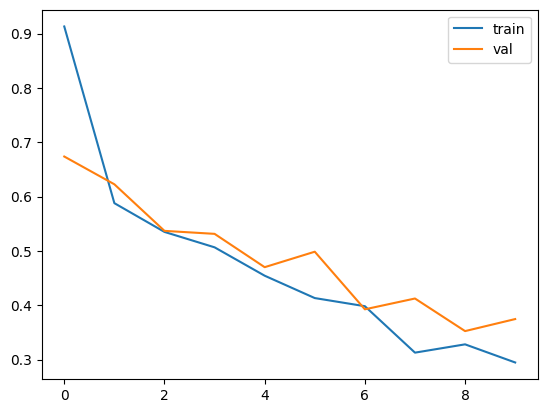

In [12]:
plt.plot(trainer.train_loss, label="train")
plt.plot(trainer.val_loss, label="val")
plt.legend()
plt.show()

In [10]:
trainer.predict(test_loader)

KeyboardInterrupt: 